# Dynamic Programming
Dynamic programming is a method for designing algorithms. An algorithm designed with dynamic programming divides the problem into subproblems, and puts them together to form a complete solution to the problem we want to solve.

To design an algorithm for a problem using dynamic programming, the problem we want to solve must have these two properties:
* **Overlapping Subproblems:** Means that the problem can be broken down into smaller subproblems, where the solutions to the subproblems are overlapping. Having subproblems that are overlapping means that the solution to one subproblem is part of the solution to another subproblem.
* **Optimal Substructure:** Means that the complete solution to a problem can be constructed from the solutions of its smaller subproblems. So not only must the subproblem have overlapping subproblems, the substructure must also be optimal so that there is a way to piece the solutions to the subproblems together to form the complete solution.

## Memoization
- Memoization is a technique where results are stored to avoid doing the same computations many times.
- When memoization is used to improve recursive algorithms, it is called a "top-down" approach because of how it starts with the main problem and breaks it into smaller subproblems.
### Using Memoization to find the Nth Fibonacci number
The nth Fibionacci number can be found using recursion.

The problem with this implementation is that the number of computations and recursive calls "explodes" when trying to find a higher fibonacci number, because the same computations are done over and over again.

In [1]:
def F(n):
    print('Computing F('+str(n)+')')
    if n<=1:
        return n
    else:
        return F(n-1)+F(n-2)
print('F(6)=',F(6))

Computing F(6)
Computing F(5)
Computing F(4)
Computing F(3)
Computing F(2)
Computing F(1)
Computing F(0)
Computing F(1)
Computing F(2)
Computing F(1)
Computing F(0)
Computing F(3)
Computing F(2)
Computing F(1)
Computing F(0)
Computing F(1)
Computing F(4)
Computing F(3)
Computing F(2)
Computing F(1)
Computing F(0)
Computing F(1)
Computing F(2)
Computing F(1)
Computing F(0)
F(6)= 8


There are 25 computations, with ther same computations done many times, even for just finding the 6th Fibonacci number.

But using memoization can help finding the nth Fibonacci number using recursion much more effectively.

We use memoization by creating an array memo to hold the Fibonacci numbers, so that Fibonacci number n can be found as element memo[n]. And we only compute the fibonacci number if it does not already exist in the memo array.

In [2]:
def F(n):
    if memo[n]!=None: #already computed
        return memo[n]
    else: #computation needed
        print('Computing F('+str(n)+')')
        if n<= 1:
            memo[n]=n
        else:
            memo[n]=F(n-1)+F(n-2)
        return memo[n]
memo=[None]*7
print('F(6)=', F(6))
print('memo=', memo)

Computing F(6)
Computing F(5)
Computing F(4)
Computing F(3)
Computing F(2)
Computing F(1)
Computing F(0)
F(6)= 8
memo= [0, 1, 1, 2, 3, 5, 8]


Memoization is very helpful to reduce the number of computations. The benefit of using memoization increases really fast by how high the Fibonacci number we want to find is.

Finding the 30th Fibonacci number requires 2 692 537 computations in the initial code, but it just requires 31 computations in the algorithm implemented using memoization!

In [3]:
computation_count=0
def F(n):
    global computation_count
    computation_count+=1
    if n<=1:
        return n
    else:
        return F(n-1)+F(n-2)
computation_count_mem=0
def F_mem(n):
    if memo[n]!=None:
        return memo[n]
    else:# Computation needed
        global computation_count_mem
        computation_count_mem+=1
        if n<=1:
            memo[n]=n
        else:
            memo[n]=F_mem(n-1)+F_mem(n-2)
        return memo[n]
print('F(30)=',F(30))
print(f'Number of computations:{computation_count}')
print('\nUsing memoization:')
memo=[None]*31
print('F(30)=',F_mem(30))
print(f'Number of computations with memoization:{computation_count_mem}')
    

F(30)= 832040
Number of computations:2692537

Using memoization:
F(30)= 832040
Number of computations with memoization:31


### Memoization in AVL trees
An AVL tree is a type of Binary tree that is self-balancing.

Every time a node is inserted or deleted from an AVL tree, the balancing factor must be calculated for all ancestors, using the height of the left and right subtrees to find out if a rotation is needed to restore balance. 

To avoid calculating the height of each node (going all the way down to the leaf nodes) to calculate the balancing factors, each node has its subtree height stored.

In [3]:
class TreeNode:
    def __init__(self,data):
        self.data=data
        self.left=None
        self.right=None
        self.height=1
def getHeight(node):
    if not node:
        return 0
    return node.height
def getBalance(node):
    if not node:
        return 0
    return getHeight(node.left) - getHeight(node.right)

def rightRotate(y):
    print('Rotate right on node',y.data)
    x=y.left
    T2=x.right
    x.right=y
    y.left=T2
    y.height=1+max(getHeight(y.left), 
    getHeight(y.right))
    x.height=1+max(getHeight(x.left),getHeight(x.right))
    return x
def leftRotate(x):
    print('Rotate left on node',x.data)
    y=x.right
    T2=y.left
    y.left=x
    x.right=T2
    x.height=1+max(getHeight(x.left),getHeight(x.right))
    y.height=1+max(getHeight(y.left),getHeight(y.right))
    return y
def insert(node, data):
    if not node:
        return TreeNode(data)

    if data < node.data:
        node.left = insert(node.left, data)
    elif data > node.data:
        node.right = insert(node.right, data)

    # Update the balance factor and balance the tree
    node.height = 1 + max(getHeight(node.left), getHeight(node.right))
    balance = getBalance(node)

    # Balancing the tree
    # Left Left
    if balance > 1 and getBalance(node.left) >= 0:
        return rightRotate(node)

    # Left Right
    if balance > 1 and getBalance(node.left) < 0:
        node.left = leftRotate(node.left)
        return rightRotate(node)

    # Right Right
    if balance < -1 and getBalance(node.right) <= 0:
        return leftRotate(node)

    # Right Left
    if balance < -1 and getBalance(node.right) > 0:
        node.right = rightRotate(node.right)
        return leftRotate(node)

    return node

def inOrderTraversal(node):
    if node is None:
        return
    inOrderTraversal(node.left)
    print(node.data, end=", ")
    inOrderTraversal(node.right)

# Inserting nodes
root = None
letters = ['C', 'B', 'E', 'A', 'D', 'H', 'G', 'F']
for letter in letters:
    root = insert(root, letter)

inOrderTraversal(root)


Rotate right on node H
A, B, C, D, E, F, G, H, 

This means that to find the balance factor for a node, the already stored left child's height is subtracted from the already stored right child's height, no other calculations needed.

Storing height in AVL trees is a form of memoization, because values are stored to avoid recalculating them. In AVL treese, when the height is stored like this, it is called an **augmented property**.

An **Augmented property** is a property of an element that does not have to be stored, but is stored to make operations more efficient.

The node heights must be calculated at some point of course, but that is only done when strictly needed, using retracing.

## The 0/1 Knapsackproblem

The 0/1 Knapsack problem states that you a backpack with a weight limit, and you are in a room full of treasures, each treasure with a value and a weight.

To solve the 0/1 Knapsack problem you must figure out which treasures to pack to maximise the total value, and at the same time keeping below the backpack's weight limit.

**Rule**:
* Every item has a weight and value
* Your knapsack has a weight limit
* Choose which items you want to bring with you in the knapsack
* You can either take an item or not, you cannot take half of an item for example
**Goal**:
* Maximise the total value of the items in the knapsack

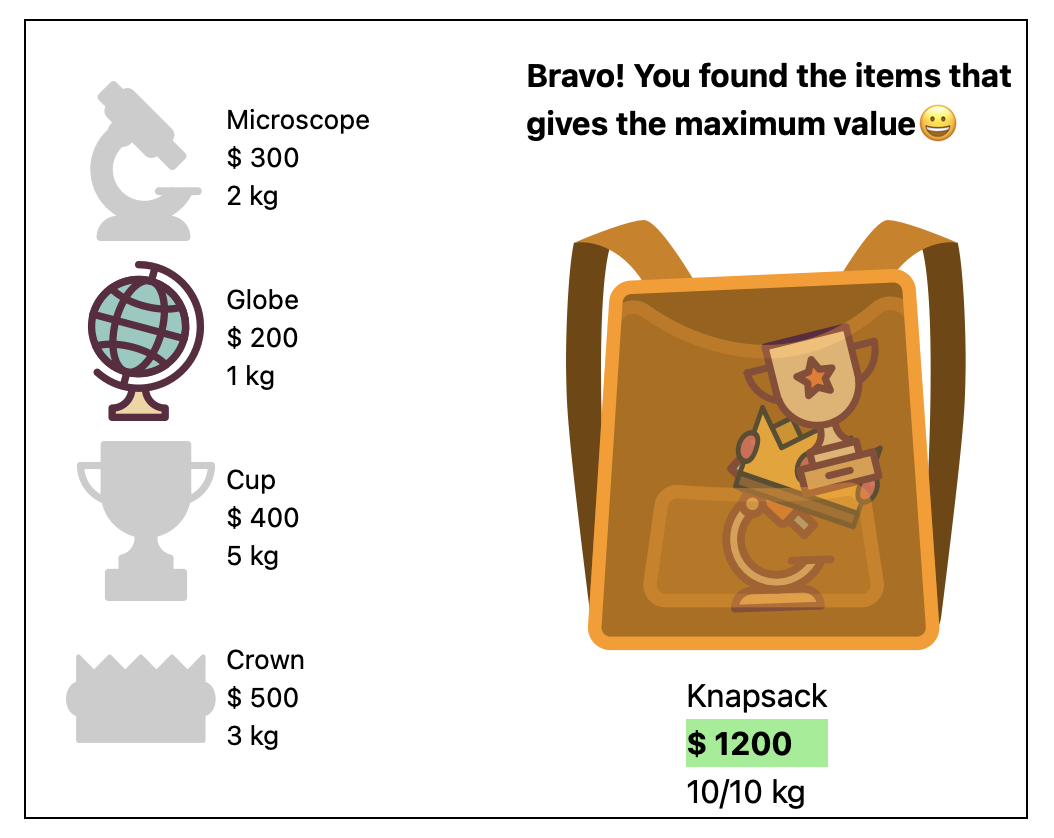

#### The Brute Force Approach 
Using brute force means to just check all possibilities, looking for the best result. This is usually the most straight forward way of solving problem, but it also requires the most calculations.

To solve the 0/1 Knapsack Problem using brute force means to:
1. Calculate the value of every possible combination of items in the kanpsack.
2. Discard the combinations that are heavier than the knapsack weight limit.
3. Choose the combination of items with the highest total value

**How it works**
1. Consider each item one at a time
   a. If there is capacity left for the current item, add it by adding its value and reducing the remaining capacity with its weight. Then call the function on itself for the next item.
   b. Also, try not adding the current item before calling the function on itself for the next item.
2. Return the maximum value from the two scenarios above (adding the current item, or not adding it).

In [4]:
def knapsack_brute_force(capacity,n):
    print(f"knapsack_brute_force({capacity},{n}")
    if n==0 or capacity==0:
        return 0
    elif weights[n-1]>capacity:
        return knapsack_brute_force(capacity, n-1)
    else:
        include_item=values[n-1]+knapsack_brute_force(capacity-weights[n-1],n-1)
        exclude_item=knapsack_brute_force(capacity,n-1)
        return max(include_item, exclude_item)

values=[300,200,400,500]
weights=[2,1,5,3]
capacity=10
n=len(values)

print("\nMaximum value in Knapsack=",knapsack_brute_force(capacity,n))

knapsack_brute_force(10,4
knapsack_brute_force(7,3
knapsack_brute_force(2,2
knapsack_brute_force(1,1
knapsack_brute_force(1,0
knapsack_brute_force(2,1
knapsack_brute_force(0,0
knapsack_brute_force(2,0
knapsack_brute_force(7,2
knapsack_brute_force(6,1
knapsack_brute_force(4,0
knapsack_brute_force(6,0
knapsack_brute_force(7,1
knapsack_brute_force(5,0
knapsack_brute_force(7,0
knapsack_brute_force(10,3
knapsack_brute_force(5,2
knapsack_brute_force(4,1
knapsack_brute_force(2,0
knapsack_brute_force(4,0
knapsack_brute_force(5,1
knapsack_brute_force(3,0
knapsack_brute_force(5,0
knapsack_brute_force(10,2
knapsack_brute_force(9,1
knapsack_brute_force(7,0
knapsack_brute_force(9,0
knapsack_brute_force(10,1
knapsack_brute_force(8,0
knapsack_brute_force(10,0

Maximum value in Knapsack= 1200


Running the code above means that the *knapsack_brute_force* function is called many times recursively. 

Every time the function is called, it will either include the current item *n-1* or not.

**Line 2**: This print statement shows us each time the function is called.
**Line 3-4**: If we run out of item to check (n==0), or we run out of capacity (capacity==0), we do not do any more recursive calls because no more items can be added to the knapsack at this point.
**Line 6-7**: If the current item is heavier than the capacity (weights[n-1]>capacity), forget the current item and go to the next item.
**Line 10-12**: If the current item can be added to the knapsack, see what gives you the highest value:adding the current item, or not adding the current item.
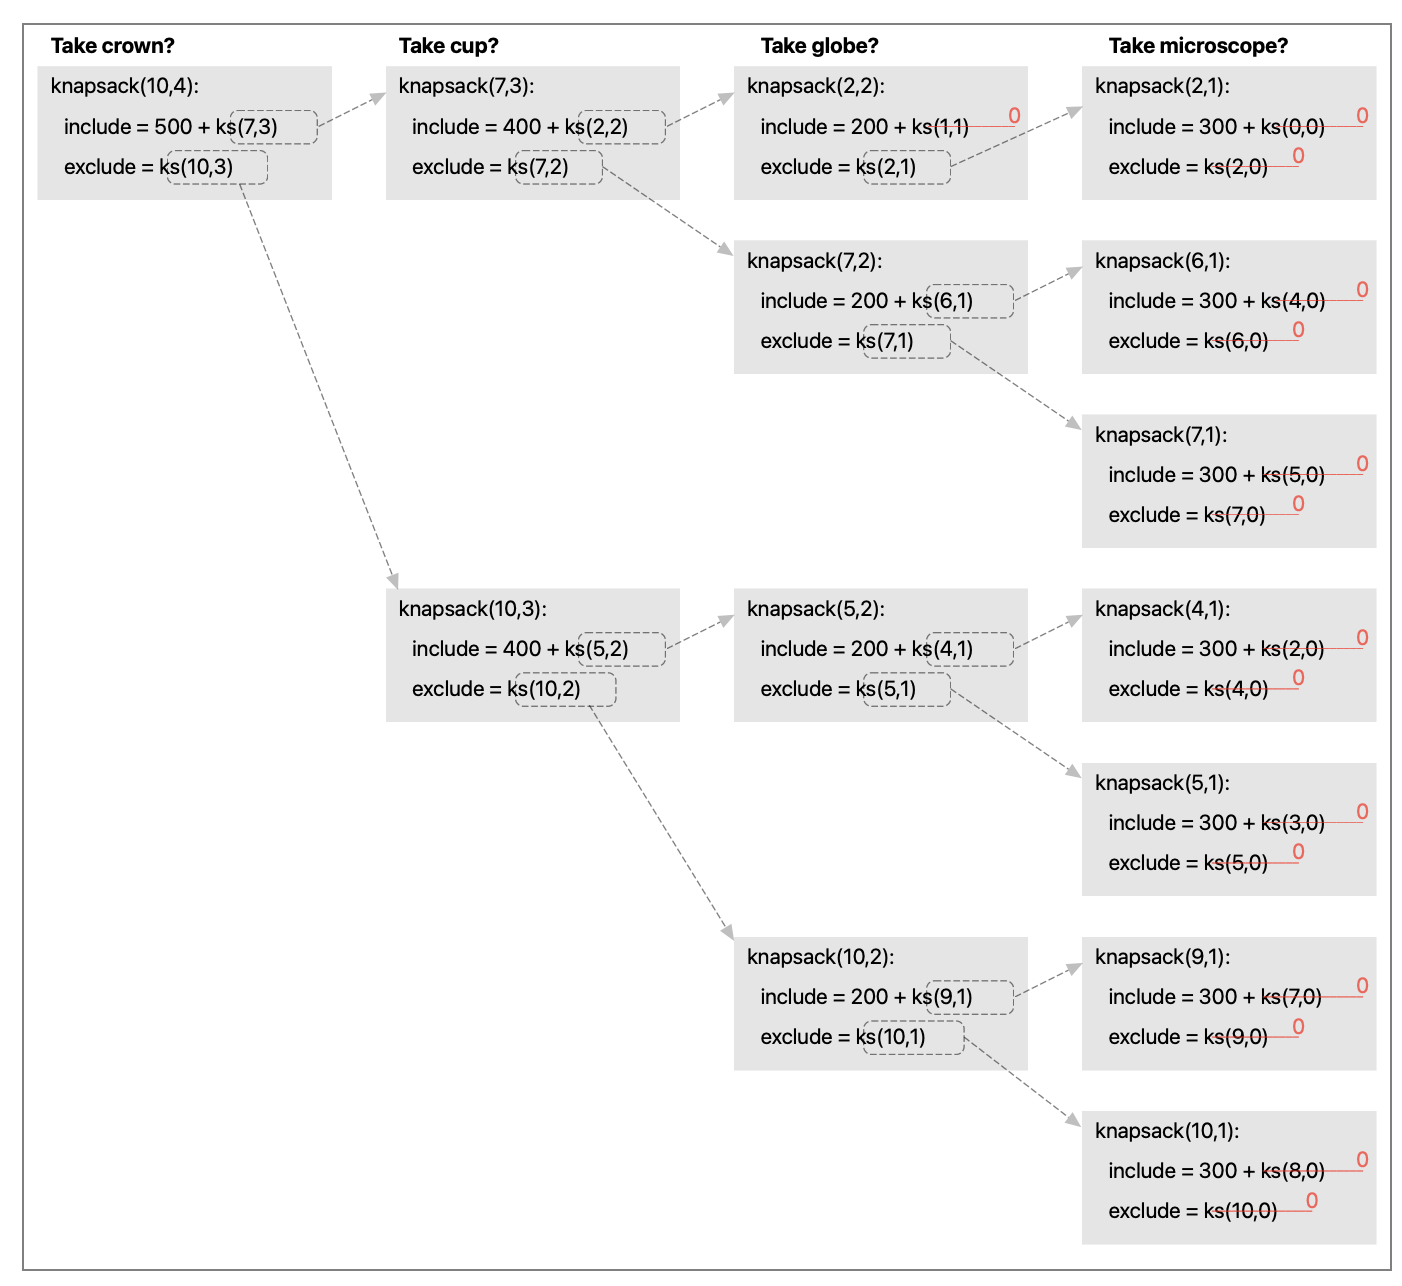

From the recursion tree above, it is possible to see that for example taking the crown, the cup, and the globe, means that there is no space left for the microscope (2kg), and that gives us a total value of 200+400+500=1100.

We can see that the only taking the microscope give us a total value of 300. It can be seen that the function is sometimes called with the same arguments, like knapsack_brute_force(2,0) is for example called two times. We avoid this by using memoization.

### The memoization approach (top-down)
The memoization technique stores the previous function call results in an array, so that previous results can be fetched from that array and does not have to be calculated again.

Memoization is a 'top down' approach because it starts solving the problem by working its way down to smaller and smaller subproblems.

In the brute force example above, the same function calls happen pnly a few times, so the effect of using memoization is not so big. But in far more items to choose from, the memoization technique would be helpful.

**How it works:**
1. In addition to the initial brute force code above, create an array  *memo* to store previous results.
2. For every function call with arguements for capacity *c* and the item number *i*, store the result in *memo[c,i]*
3. To avoid doing the same calculation more than once, every time the function is called with arguements *c* and *i*, check if the result is already stored in *memo[c,i]*.

In [4]:
def knapsack_memoization(capacity,n):
    print(f"knapsack_memoization({n},{capacity})")
    if memo[n][capacity] is not None:
        print(f"Using memo for ({n},{capacity})")
        return memo[n][capacity]
    if n==0 or capacity==0:
        result =0
    elif weights[n-1]>capacity:
        result=knapsack_memoization(capacity,n-1)
    else:
        include_item=values[n-1]+knapsack_memoization(capacity-weights[n-1],n-1)
        exclude_item=knapsack_memoization(capacity,n-1)
        result=max(include_item,exclude_item)
    memo[n][capacity]=result
    return result
values=[300,200,400,500]
weights=[2,1,5,3]
capacity=10
n=len(values)

memo=[[None]*(capacity+1) for _ in range(n+1)]
print("\n Maximum value in Knapsack=",knapsack_memoization(capacity,n))

knapsack_memoization(4,10)
knapsack_memoization(3,7)
knapsack_memoization(2,2)
knapsack_memoization(1,1)
knapsack_memoization(0,1)
knapsack_memoization(1,2)
knapsack_memoization(0,0)
knapsack_memoization(0,2)
knapsack_memoization(2,7)
knapsack_memoization(1,6)
knapsack_memoization(0,4)
knapsack_memoization(0,6)
knapsack_memoization(1,7)
knapsack_memoization(0,5)
knapsack_memoization(0,7)
knapsack_memoization(3,10)
knapsack_memoization(2,5)
knapsack_memoization(1,4)
knapsack_memoization(0,2)
Using memo for (0,2)
knapsack_memoization(0,4)
Using memo for (0,4)
knapsack_memoization(1,5)
knapsack_memoization(0,3)
knapsack_memoization(0,5)
Using memo for (0,5)
knapsack_memoization(2,10)
knapsack_memoization(1,9)
knapsack_memoization(0,7)
Using memo for (0,7)
knapsack_memoization(0,9)
knapsack_memoization(1,10)
knapsack_memoization(0,8)
knapsack_memoization(0,10)

 Maximum value in Knapsack= 1200


### The tabulation approach (bottom-up)
Another technique to solve the 0/1 Knapsack problem is to use something called tabulation. This approach is also called the iterative approach, and is a technique used in *dynamic programming*. 

Tabulation solves the problem in a bottom-up manner by filling up a table with the results from the most basic subproblems first.The next table values are filled in using the previous results.

**How it works**:
1. Consider one item at a time, and increase the knapsack capacity from 0 to the knapsack limit.
2. If the current itoem is not too heavy, check what gives the highest value: adding it or not adding it. Store the maximum of these two values in the table.
3. In case the current item is too heavy to be added, just use the previously calculated value at the current capacity where the current item was not considered.

The tabulation approach works by considering one item at a time, for increasing knapsack capacbilities. In this way the solution is built up by solving the most basic subproblems first.

On each row an item is considered to be added to knapsack, for increasing capactities.

In [ ]:
def knapsack_tabulation():
    n=len(values)
    tab=[[0]*(capacity+1) for y in range(n+1)]

    for i in range(1,n+1):
        for w in range(1, capacity+1):
            if weights[i-1]<=w:
                include_item=values[i-1]+tab[i-1][w-weights[i-1]]
                exclude_item=tab[i-1][w]
                tab[i][w]=max(include_item, exclude_item)
            else:
                tab[i][w]=tab[i-1][w]
    for row in tab:
        print(row)
    return tab[n][capacity]

values=[300,200,400,500]
weights=[2,1,5,3]
capacity=10
print("\nMaximum value in Knapsack=", knapsack_tabulation())

In [3]:
def knapsack_tabulation():
    n = len(values)
    tab = [[0]*(capacity + 1) for y in range(n + 1)]

    for i in range(1, n+1):
        for w in range(1, capacity+1):
            if weights[i-1] <= w:
                include_item = values[i-1] + tab[i-1][w-weights[i-1]]
                exclude_item = tab[i-1][w]
                tab[i][w] = max(include_item, exclude_item)
            else:
                tab[i][w] = tab[i-1][w]
    
    for row in tab:
    	  print(row)
    return tab[n][capacity]

values = [300, 200, 400, 500]
weights = [2, 1, 5, 3]
capacity=10
print("\nMaximum value in Knapsack=", knapsack_tabulation())

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 300, 300, 300, 300, 300, 300, 300, 300, 300]
[0, 200, 300, 500, 500, 500, 500, 500, 500, 500, 500]
[0, 200, 300, 500, 500, 500, 600, 700, 900, 900, 900]
[0, 200, 300, 500, 700, 800, 1000, 1000, 1000, 1100, 1200]

Maximum value in Knapsack= 1200


**Line 7-10**: If the item weight is lower than the capacity, it means that it can be added. Check if adding it gives a higher total value than the result calculated in the previous row, which represents not adding the item. Use the highest (max) of these two values. In other words: *Choose to take, or not to take, the current item*.

**Line 8**: This line might be the hardest to understand. To find the value that corresponds to adding the current item, we must use the current item's value from the *values* array. But in addition, we must reduce the capacity with the current item's weight, to see if the remaining capacity can give us additional value. This is similar to check if other items can be added in addition to the current item, and adding the value of those items.

**Line 12**: In case the current item is heavier that the the capacity (too heavy), just fill in the value from the previous line, wheich represnts not adding the current item.

### Which items gives us the highest value?
After filling out the table and finding the maximum value the knapsack can have, it is not obvious which item we need to pack with us to get that value.

To find the included items, we use the table we have created, and we start with the bottom right cell with the highest value, in our case the cell with value 1200 in it.

**Steps to find the included items:**
1. Start with bottom right cell (the cell with the highest value).
2. If the cell above has the same value, it means that this row's item is not included, and we go to the cell above.
3. If the cell above has a different value, it means that the current row's item is included, and we move to the row above, and we move to the left as many times as the weight of the included item.
4. The cup weights 5kg, so the next cell we go to is on the row above, and 5 places to the left, to the cell with value 300, on the row where the globe is considered.
5. The cell above has the same value 300, which means the globe is not included, and the next cell we go is the cell right above with value 300 where the microscope is considered.
6. Since the cell above is different than the current cell with value 300, it means the microscope is included.
7. The next cell we go to is on the line above, and two places to the left because the microscope is 2kg.
8. We arrive at the upper leftmost cell. Since the value is 0, it means we are finished.

Our 0/1 Knapsack problem has maximum value when these item are included: the crown, the cup and the microscope.

The same steps are added to the code below 👇, to find the items that make up the solution to the 0/1 Knapsack problem.

In [10]:
def knapsack_tabulation():
    n = len(values)
    tab = [[0] * (capacity + 1) for _ in range(n + 1)]

    for i in range(1, n + 1):
        for w in range(1, capacity + 1):
            if weights[i-1] <= w:
                include_item = values[i-1] + tab[i-1][w - weights[i-1]]
                exclude_item = tab[i-1][w]
                tab[i][w] = max(include_item, exclude_item)
            else:
                tab[i][w] = tab[i-1][w]

    for row in tab:
        print(row)

    items_included = []
    w = capacity
    for i in range(n, 0, -1):
        if tab[i][w] != tab[i-1][w]:
            items_included.append(i-1)
            w -= weights[i-1]

    print("\nItems included:", items_included)

    return tab[n][capacity]

values = [300, 200, 400,500]
weights=[2,1,5,3]
capacity=10
print("\nMaximum value in Knapsack=",knapsack_tabulation())

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 300, 300, 300, 300, 300, 300, 300, 300, 300]
[0, 200, 300, 500, 500, 500, 500, 500, 500, 500, 500]
[0, 200, 300, 500, 500, 500, 600, 700, 900, 900, 900]
[0, 200, 300, 500, 700, 800, 1000, 1000, 1000, 1100, 1200]

Items included: [3, 2, 0]

Maximum value in Knapsack= 1200


### Time Complexity
The three approaches to solving the 0/1 Knapsack problem run differently, and with different time complexities.

**Brute Force Approach**: This is the slowest of the three approaches. The possibilities are checked recursively, with the time complexity O(2^n), where n is the number of potential items we can pack. This means the number of computations double for each extra item that needs to be considered.

**Memoization Approach**: Saves computations by remembering previous results, which results in a better time complexity O(n.C), where n is the number of items, and C is the knapsack capacity. This approach runs otherwise in the same recursive way as the brute force approach.

**Tabulation Approach**: Has the same time complexity as the memoization approach O(n•C), where n is the number of items, amd C is the Knapsack capacity, but memory usage and the way it runs is more predictable, which normally makes the tabulation approach the most favourable.

